In [106]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import yfinance as yf
from argparse import Namespace
from copy import deepcopy as dc



def prepare_dataframe_for_lstm(df, n_steps):
    df = dc(df)

    #df.set_index('Date', inplace=True)

    for i in range(1, n_steps+1):
        df[f'Close(t-{i})'] = df['Close'].shift(i)

    df.dropna(inplace=True)

    return df
def get_company_data(ticker,start,end):
    data = yf.download(ticker, start=start, end=end)
    data.drop(columns=['Open','High','Low','Adj Close','Volume'],inplace=True)
    return data

In [107]:
class LSTM(nn.Module):
    def __init__(self, input_size, hidden_size, num_stacked_layers):
        super().__init__()
        self.hidden_size = hidden_size
        self.num_stacked_layers = num_stacked_layers

        self.lstm = nn.LSTM(input_size, hidden_size, num_stacked_layers,
                            batch_first=True)

        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        batch_size = x.size(0)
        h0 = torch.zeros(self.num_stacked_layers, batch_size, self.hidden_size).to(device)
        c0 = torch.zeros(self.num_stacked_layers, batch_size, self.hidden_size).to(device)

        out, _ = self.lstm(x, (h0, c0))
        out = self.fc(out[:, -1, :])
        return out

[*********************100%%**********************]  1 of 1 completed


(6742, 1)
(6737, 6)
               Close
Date                
1997-05-15  0.097917
1997-05-16  0.086458
1997-05-19  0.085417
1997-05-20  0.081771
1997-05-21  0.071354
1997-05-22  0.069792
1997-05-23  0.075000
1997-05-27  0.079167
1997-05-28  0.076563
1997-05-29  0.075260
               Close  Close(t-1)  Close(t-2)  Close(t-3)  Close(t-4)  \
Date                                                                   
1997-05-22  0.069792    0.071354    0.081771    0.085417    0.086458   
1997-05-23  0.075000    0.069792    0.071354    0.081771    0.085417   
1997-05-27  0.079167    0.075000    0.069792    0.071354    0.081771   
1997-05-28  0.076563    0.079167    0.075000    0.069792    0.071354   
1997-05-29  0.075260    0.076563    0.079167    0.075000    0.069792   

            Close(t-5)  
Date                    
1997-05-22    0.097917  
1997-05-23    0.086458  
1997-05-27    0.085417  
1997-05-28    0.081771  
1997-05-29    0.071354  
               Close  Close(t-1)  Close(t-2)  Cl

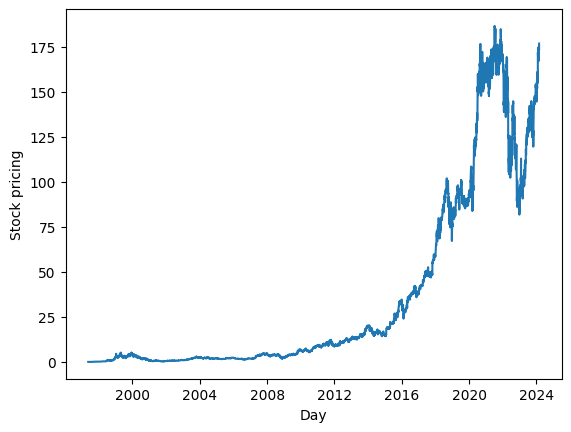

In [108]:
device = 'cuda:0' if torch.cuda.is_available() else 'cpu'

args=Namespace(company='AMZN',start='1997-01-01',end='2024-03-01',lr=0.001,batch_size=8,lookback=5,number_epoch=50,number_hidden=4)


data=get_company_data(args.company,args.start,args.end)
print (data.shape)
plt.plot(data.index,data['Close'])
plt.xlabel('Day')
plt.ylabel('Stock pricing')
shifted_df=prepare_dataframe_for_lstm(data,args.lookback)
shifted_df_as_np = shifted_df.to_numpy()
print (shifted_df.shape)
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler(feature_range=(-1, 1))
shifted_df_as_np = scaler.fit_transform(shifted_df_as_np)
X = shifted_df_as_np[:, 1:]
y = shifted_df_as_np[:, 0]
X = dc(np.flip(X, axis=1))
split_index = int(len(X) * 0.95)
X_train = X[:split_index]
X_test = X[split_index:]

y_train = y[:split_index]
y_test = y[split_index:]

X_train = X_train.reshape((-1, args.lookback, 1))
X_test = X_test.reshape((-1, args.lookback, 1))

y_train = y_train.reshape((-1, 1))
y_test = y_test.reshape((-1, 1))


X_train = torch.tensor(X_train).float()
y_train = torch.tensor(y_train).float()
X_test = torch.tensor(X_test).float()
y_test = torch.tensor(y_test).float()
print (data.head(10))
print (shifted_df.head())
print (shifted_df.head())

In [109]:
from torch.utils.data import Dataset

class TimeSeriesDataset(Dataset):
    def __init__(self, X, y):
        self.X = X
        self.y = y

    def __len__(self):
        return len(self.X)

    def __getitem__(self, i):
        return self.X[i], self.y[i]

train_dataset = TimeSeriesDataset(X_train, y_train)
test_dataset = TimeSeriesDataset(X_test, y_test)

In [110]:
from torch.utils.data import DataLoader

batch_size = args.batch_size

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

In [111]:
model = LSTM(1, args.number_hidden, 1)
model.to(device)
def train_one_epoch():
    model.train(True)
    print(f'Epoch: {epoch + 1}')
    running_loss = 0.0

    for batch_index, batch in enumerate(train_loader):
        x_batch, y_batch = batch[0].to(device), batch[1].to(device)

        output = model(x_batch)
        loss = loss_function(output, y_batch)
        running_loss += loss.item()

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()


    avg_loss_across_batches = running_loss / (batch_index+1)
    print('Training Loss: {}'.format(avg_loss_across_batches))

    print()
    return avg_loss_across_batches

def validate_one_epoch():
    model.train(False)
    running_loss = 0.0

    for batch_index, batch in enumerate(test_loader):
        x_batch, y_batch = batch[0].to(device), batch[1].to(device)

        with torch.no_grad():
            output = model(x_batch)
            loss = loss_function(output, y_batch)
            running_loss += loss.item()

    avg_loss_across_batches = running_loss / (batch_index+1)

    print('Val Loss: {0:.7f}'.format(avg_loss_across_batches))
    print('***************************************************')
    print()
    return avg_loss_across_batches

In [112]:
loss_function = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=args.lr)

residual=pd.DataFrame(columns=['epoch','training_loss','val_loss'])
for epoch in range(args.number_epoch):
    train_loss=train_one_epoch()
    val_loss=validate_one_epoch()
    residual.loc[len(residual)]=[epoch,train_loss,val_loss]


Epoch: 1
Training Loss: 0.2201725782713129

Val Loss: 0.0179434
***************************************************

Epoch: 2
Training Loss: 0.0024330333950820203

Val Loss: 0.0032922
***************************************************

Epoch: 3
Training Loss: 0.0005576501203643147

Val Loss: 0.0022725
***************************************************

Epoch: 4
Training Loss: 0.00046383753260556657

Val Loss: 0.0018410
***************************************************

Epoch: 5
Training Loss: 0.00041879181060210156

Val Loss: 0.0016526
***************************************************

Epoch: 6
Training Loss: 0.0003962811955096868

Val Loss: 0.0019997
***************************************************

Epoch: 7
Training Loss: 0.00037466433242940413

Val Loss: 0.0016131
***************************************************

Epoch: 8
Training Loss: 0.0003528018171002145

Val Loss: 0.0015645
***************************************************

Epoch: 9
Training Loss: 0.00032743871119

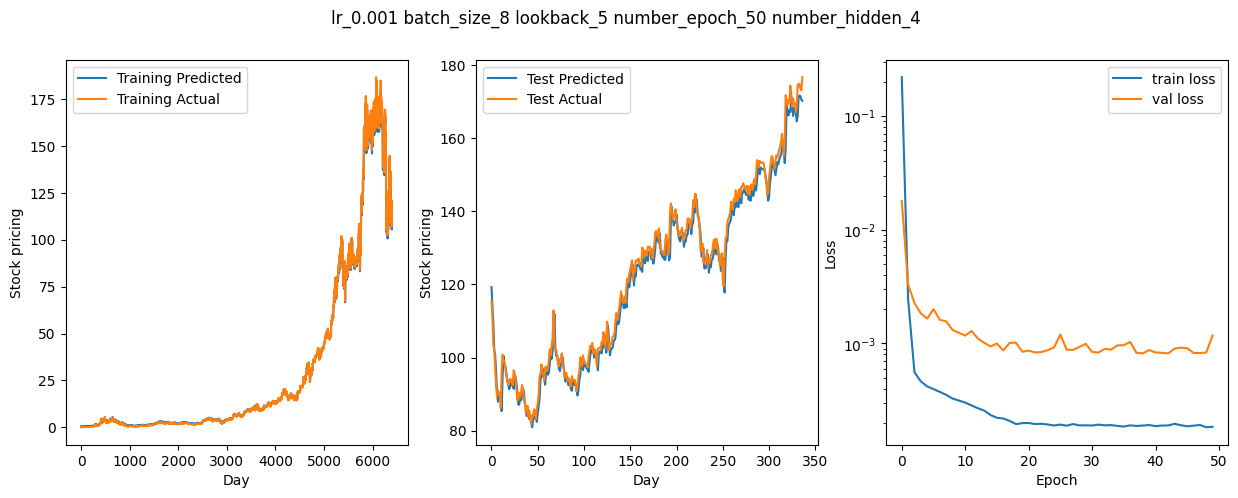

In [113]:
def get_model_name():
  d=vars(args)
  name=''
  for k,v in d.items():
    if k !='company' and k !='start' and k!='end':
      name+=k+'_'+str(v)+' '
  return name


#prediction in real-scale
def get_prediction(X,y):
  with torch.no_grad():
    predicted = model(X.to(device)).to('cpu').numpy()
  predictions = predicted.flatten()
  dummies = np.zeros((X.shape[0], args.lookback+1))
  dummies[:, 0] = predictions
  dummies = scaler.inverse_transform(dummies)
  predictions = dc(dummies[:, 0])
  dummies_2 = np.zeros((X.shape[0], args.lookback+1))
  dummies_2[:,0]=y.flatten()
  dummies_2=scaler.inverse_transform(dummies_2)
  new_y=dc(dummies_2[:,0])
  return predictions,new_y

pred_train,new_y_train=get_prediction(X_train,y_train)
pred_test,new_y_test=get_prediction(X_test,y_test)

get_model_name()
fig,ax=plt.subplots(1,3,figsize=(15,5))
fig.suptitle(get_model_name())
#print (scaler.inverse_transform(y_train))
ax[0].plot(pred_train,label='Training Predicted')
ax[0].plot(new_y_train,label='Training Actual')
ax[0].set_xlabel('Day')
ax[0].set_ylabel('Stock pricing')
ax[0].legend()

ax[1].plot(pred_test,label='Test Predicted')
ax[1].plot(new_y_test,label='Test Actual')
ax[1].set_xlabel('Day')
ax[1].set_ylabel('Stock pricing')
ax[1].legend()


ax[2].plot(residual['epoch'],residual['training_loss'],label='train loss')
ax[2].plot(residual['epoch'],residual['val_loss'],label='val loss')
ax[2].set_yscale('log')
ax[2].set_xlabel('Epoch')
ax[2].set_ylabel('Loss')


ax[2].legend()